In [44]:
import pandas as pd
import numpy as np 
import sklearn
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import f1_score
from sklearn.metrics import fbeta_score
from sklearn.metrics import average_precision_score
from tqdm import tqdm
from sklearn.preprocessing import StandardScaler

In [45]:
df = pd.read_csv('data.csv')
df.head()

,Bankrupt?,ROA(C) before interest and depreciation before interest,ROA(A) before interest and % after tax,ROA(B) before interest and depreciation after tax,Operating Gross Margin,Realized Sales Gross Margin,Operating Profit Rate,Pre-tax net Interest Rate,After-tax net Interest Rate,Non-industry income and expenditure/revenue,...,Net Income to Total Assets,Total assets to GNP price,No-credit Interval,Gross Profit to Sales,Net Income to Stockholder's Equity,Liability to Equity,Degree of Financial Leverage (DFL),Interest Coverage Ratio (Interest expense to EBIT),Net Income Flag,Equity to Liability
0,1,0.370594,0.424389,0.405750,0.601457,0.601457,0.998969,0.796887,0.808809,0.302646,...,0.716845,0.009219,0.622879,0.601453,0.827890,0.290202,0.026601,0.564050,1,0.016469
1,1,0.464291,0.538214,0.516730,0.610235,0.610235,0.998946,0.797380,0.809301,0.303556,...,0.795297,0.008323,0.623652,0.610237,0.839969,0.283846,0.264577,0.570175,1,0.020794
2,1,0.426071,0.499019,0.472295,0.601450,0.601364,0.998857,0.796403,0.808388,0.302035,...,0.774670,0.040003,0.623841,0.601449,0.836774,0.290189,0.026555,0.563706,1,0.016474
3,1,0.399844,0.451265,0.457733,0.583541,0.583541,0.998700,0.796967,0.808966,0.303350,...,0.739555,0.003252,0.622929,0.583538,0.834697,0.281721,0.026697,0.564663,1,0.023982
4,1,0.465022,0.538432,0.522298,0.598783,0.598783,0.998973,0.797366,0.809304,0.303475,...,0.795016,0.003878,0.623521,0.598782,0.839973,0.278514,0.024752,0.575617,1,0.035490


## The dataset consists of 6819 enterprise, 96 attributes. 

In [46]:
df.describe()

,Bankrupt?,ROA(C) before interest and depreciation before interest,ROA(A) before interest and % after tax,ROA(B) before interest and depreciation after tax,Operating Gross Margin,Realized Sales Gross Margin,Operating Profit Rate,Pre-tax net Interest Rate,After-tax net Interest Rate,Non-industry income and expenditure/revenue,...,Net Income to Total Assets,Total assets to GNP price,No-credit Interval,Gross Profit to Sales,Net Income to Stockholder's Equity,Liability to Equity,Degree of Financial Leverage (DFL),Interest Coverage Ratio (Interest expense to EBIT),Net Income Flag,Equity to Liability
count,6819.000000,6819.000000,6819.000000,6819.000000,6819.000000,6819.000000,6819.000000,6819.000000,6819.000000,6819.000000,...,6819.000000,6.819000e+03,6819.000000,6819.000000,6819.000000,6819.000000,6819.000000,6819.000000,6819.0,6819.000000
mean,0.032263,0.505180,0.558625,0.553589,0.607948,0.607929,0.998755,0.797190,0.809084,0.303623,...,0.807760,1.862942e+07,0.623915,0.607946,0.840402,0.280365,0.027541,0.565358,1.0,0.047578
std,0.176710,0.060686,0.065620,0.061595,0.016934,0.016916,0.013010,0.012869,0.013601,0.011163,...,0.040332,3.764501e+08,0.012290,0.016934,0.014523,0.014463,0.015668,0.013214,0.0,0.050014
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.0,0.000000
25%,0.000000,0.476527,0.535543,0.527277,0.600445,0.600434,0.998969,0.797386,0.809312,0.303466,...,0.796750,9.036205e-04,0.623636,0.600443,0.840115,0.276944,0.026791,0.565158,1.0,0.024477
50%,0.000000,0.502706,0.559802,0.552278,0.605997,0.605976,0.999022,0.797464,0.809375,0.303525,...,0.810619,2.085213e-03,0.623879,0.605998,0.841179,0.278778,0.026808,0.565252,1.0,0.033798
75%,0.000000,0.535563,0.589157,0.584105,0.613914,0.613842,0.999095,0.797579,0.809469,0.303585,...,0.826455,5.269777e-03,0.624168,0.613913,0.842357,0.281449,0.026913,0.565725,1.0,0.052838
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,9.820000e+09,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.0,1.000000


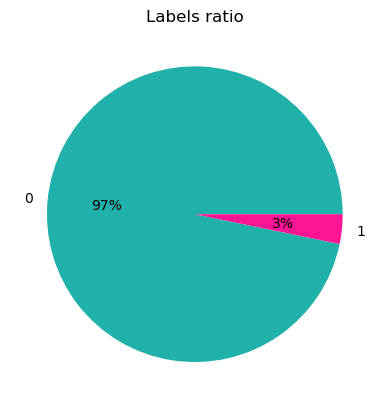

In [47]:
pred_values = dict(df["Bankrupt?"].value_counts())
colors = ["lightseagreen", "deeppink"]
plt.pie(list(pred_values.values()), labels = list(pred_values.keys()), colors = colors, autopct='%.0f%%')
plt.title("Labels ratio")
plt.show()


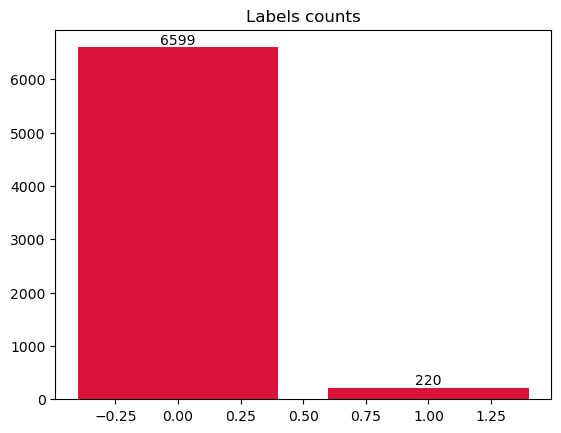

In [48]:
pred_values = dict(df["Bankrupt?"].value_counts())
fig, ax = plt.subplots()
bar_container = ax.bar(list(pred_values.keys()), list(pred_values.values()), color = "crimson")
ax.bar_label(bar_container)
plt.title("Labels counts")
plt.show()

In [49]:
predicted_variable = df['Bankrupt?']
df = df.drop(columns="Bankrupt?")
df.head()


,ROA(C) before interest and depreciation before interest,ROA(A) before interest and % after tax,ROA(B) before interest and depreciation after tax,Operating Gross Margin,Realized Sales Gross Margin,Operating Profit Rate,Pre-tax net Interest Rate,After-tax net Interest Rate,Non-industry income and expenditure/revenue,Continuous interest rate (after tax),...,Net Income to Total Assets,Total assets to GNP price,No-credit Interval,Gross Profit to Sales,Net Income to Stockholder's Equity,Liability to Equity,Degree of Financial Leverage (DFL),Interest Coverage Ratio (Interest expense to EBIT),Net Income Flag,Equity to Liability
0,0.370594,0.424389,0.405750,0.601457,0.601457,0.998969,0.796887,0.808809,0.302646,0.780985,...,0.716845,0.009219,0.622879,0.601453,0.827890,0.290202,0.026601,0.564050,1,0.016469
1,0.464291,0.538214,0.516730,0.610235,0.610235,0.998946,0.797380,0.809301,0.303556,0.781506,...,0.795297,0.008323,0.623652,0.610237,0.839969,0.283846,0.264577,0.570175,1,0.020794
2,0.426071,0.499019,0.472295,0.601450,0.601364,0.998857,0.796403,0.808388,0.302035,0.780284,...,0.774670,0.040003,0.623841,0.601449,0.836774,0.290189,0.026555,0.563706,1,0.016474
3,0.399844,0.451265,0.457733,0.583541,0.583541,0.998700,0.796967,0.808966,0.303350,0.781241,...,0.739555,0.003252,0.622929,0.583538,0.834697,0.281721,0.026697,0.564663,1,0.023982
4,0.465022,0.538432,0.522298,0.598783,0.598783,0.998973,0.797366,0.809304,0.303475,0.781550,...,0.795016,0.003878,0.623521,0.598782,0.839973,0.278514,0.024752,0.575617,1,0.035490


# Simple model

In [50]:
from sklearn.model_selection import train_test_split

X_train, X_temp, y_train, y_temp = train_test_split(df, predicted_variable, test_size=0.3, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)



In [51]:
X_train_size = len(X_train)
X_val_size = len(X_val)
X_test_size = len(X_test)
sizes = [X_train_size, X_val_size, X_test_size]
cumulative = sum(sizes)
split_ratio = [round((size / cumulative), 3) * 100 for size in sizes]
print(split_ratio)

[70.0, 15.0, 15.0]


In [52]:
from sklearn.linear_model import LogisticRegression

In [53]:
simple_log_reg = LogisticRegression(random_state=42, max_iter=2000)
simple_log_reg.fit(X_train, y_train)
y_pred = simple_log_reg.predict(X_val)

In [54]:
from sklearn import metrics

cnf_matrix = metrics.confusion_matrix(y_val, y_pred)

In [55]:
print(average_precision_score(y_val, y_pred))

0.03812316715542522


In [56]:
from sklearn.metrics import classification_report
print(classification_report(y_val, y_pred))
print(fbeta_score(y_val, y_pred, average="macro", beta = 2))

              precision    recall  f1-score   support

           0       0.96      0.99      0.98       984
           1       0.00      0.00      0.00        39

    accuracy                           0.96      1023
   macro avg       0.48      0.50      0.49      1023
weighted avg       0.92      0.96      0.94      1023

0.49323505654281097


# Sprawdzenie na zbiorze testowym

In [57]:
y_pred_1 = simple_log_reg.predict(X_test)
y_prob_1 = simple_log_reg.predict_proba(X_test)[:,1]
print(classification_report(y_test, y_pred_1))
print(fbeta_score(y_test, y_pred_1, average="macro", beta = 2))
print(average_precision_score(y_test, y_prob_1))

              precision    recall  f1-score   support

           0       0.96      1.00      0.98       984
           1       0.25      0.03      0.05        39

    accuracy                           0.96      1023
   macro avg       0.61      0.51      0.51      1023
weighted avg       0.94      0.96      0.94      1023

0.5105795913218971
0.061350674878435


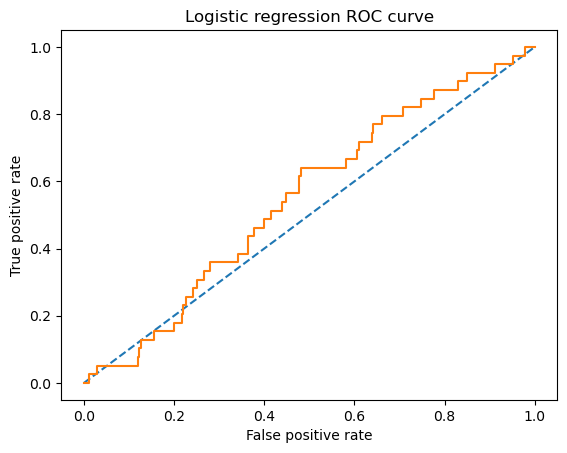

In [58]:
from sklearn.metrics import roc_curve
y_pred_prob = simple_log_reg.predict_proba(X_test)[:,1]
fpr, tpr, tresholds = roc_curve(y_val, y_pred_prob)
plt.plot([0, 1], [0, 1], "--")
plt.plot(fpr, tpr)
plt.xlabel("False positive rate")
plt.ylabel("True positive rate")
plt.title("Logistic regression ROC curve")
plt.show()

#### As we can see model is completly useless, becouse it's marcro avg is equivalent to coinflip. Let's try to improve it. If we take a look on a value counts in predicted variable it turns out that classification task is highly unbalanced. Let's compare the results with weighted simple model:

In [59]:
weights = {0: 1, 1: 32}
weighted_lr_model = LogisticRegression(random_state=42, max_iter=2000, class_weight= weights)
weighted_lr_model.fit(X_train, y_train)
y_pred_clf = weighted_lr_model.predict(X_val)
print(classification_report(y_val, y_pred_clf))
print(f1_score(y_val, y_pred_clf, average='macro'))
print(fbeta_score(y_val, y_pred_clf, average="macro", beta = 2))
print(average_precision_score(y_val, y_pred_clf))

              precision    recall  f1-score   support

           0       0.97      0.74      0.84       984
           1       0.06      0.38      0.10        39

    accuracy                           0.73      1023
   macro avg       0.51      0.56      0.47      1023
weighted avg       0.93      0.73      0.81      1023

0.467741935483871
0.4760472700242185
0.044749084982390545


In [60]:
y_pred_2 = weighted_lr_model.predict(X_test)
y_prob_2 = weighted_lr_model.predict_proba(X_test)[:,1]

print(classification_report(y_test, y_pred_2))
print(fbeta_score(y_test, y_pred_2, average="macro", beta = 2))
print(average_precision_score(y_test, y_prob_2))

              precision    recall  f1-score   support

           0       0.97      0.78      0.86       984
           1       0.07      0.44      0.12        39

    accuracy                           0.77      1023
   macro avg       0.52      0.61      0.49      1023
weighted avg       0.94      0.77      0.84      1023

0.514072451496521
0.0841801517574461


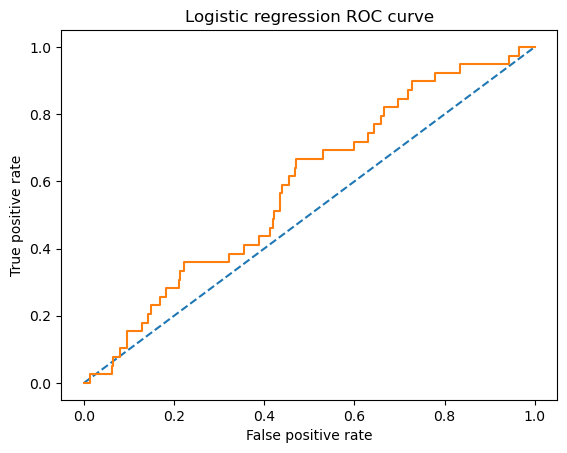

In [61]:
y_pred_prob_weighted = weighted_lr_model.predict_proba(X_test)[:,1]
fpr2, tpr2, tresholds3 = roc_curve(y_val, y_pred_prob_weighted)
plt.plot([0, 1], [0, 1], "--")
plt.plot(fpr2, tpr2)
plt.xlabel("False positive rate")
plt.ylabel("True positive rate")
plt.title("Logistic regression ROC curve")
plt.show()

# Lets try diffrent techniques

In [62]:
from sklearn.tree import DecisionTreeClassifier

In [63]:
clf = DecisionTreeClassifier(random_state=42)
clf.fit(X_train, y_train)
y_pred_clf = clf.predict(X_val)
print(classification_report(y_val, y_pred_clf))
print(f1_score(y_val, y_pred_clf, average='macro'))
print(fbeta_score(y_val, y_pred_clf, average="macro", beta = 2))

              precision    recall  f1-score   support

           0       0.97      0.97      0.97       984
           1       0.27      0.28      0.28        39

    accuracy                           0.94      1023
   macro avg       0.62      0.63      0.62      1023
weighted avg       0.94      0.94      0.94      1023

0.6227492370295016
0.6245471416509951


In [64]:
y_pred_3 = clf.predict(X_test)
y_prob_3 = clf.predict_proba(X_test)[:,1]

print(classification_report(y_test, y_pred_3))
print(fbeta_score(y_test, y_pred_3, average="macro", beta = 2))
print(round(average_precision_score(y_test, y_prob_3), 3))

              precision    recall  f1-score   support

           0       0.98      0.98      0.98       984
           1       0.41      0.38      0.39        39

    accuracy                           0.96      1023
   macro avg       0.69      0.68      0.69      1023
weighted avg       0.95      0.96      0.95      1023

0.6829230293090344
0.179


#### As we can see DesisionTree performes better. We can check it now with weights. 

In [65]:
weights_clf = {0: 1, 1: 32}
clf_weights = DecisionTreeClassifier(random_state=42, class_weight= weights_clf)
clf_weights.fit(X_train, y_train)
y_pred_clf_weights = clf_weights.predict(X_val)
print(classification_report(y_val, y_pred_clf_weights))
print(f1_score(y_val, y_pred_clf_weights, average='macro'))
print(fbeta_score(y_val, y_pred_clf_weights, average="macro", beta = 2))


              precision    recall  f1-score   support

           0       0.98      0.97      0.97       984
           1       0.33      0.38      0.36        39

    accuracy                           0.95      1023
   macro avg       0.65      0.68      0.66      1023
weighted avg       0.95      0.95      0.95      1023

0.6648099606815203
0.6719151495270899


In [66]:
y_pred_4 = clf_weights.predict(X_test)
y_prob_4 = clf_weights.predict_proba(X_test)[:,1]

print(classification_report(y_test, y_pred_4))
print(fbeta_score(y_test, y_pred_4, average="macro", beta = 2))
print(round(average_precision_score(y_test, y_pred_4), 3))

              precision    recall  f1-score   support

           0       0.97      0.98      0.97       984
           1       0.34      0.31      0.32        39

    accuracy                           0.95      1023
   macro avg       0.66      0.64      0.65      1023
weighted avg       0.95      0.95      0.95      1023

0.6449843910156898
0.132


In [67]:
from imblearn.under_sampling import TomekLinks
tl = TomekLinks(sampling_strategy="majority")

X_res, y_res = tl.fit_resample(X_train, y_train)
print(y_res.value_counts())

Bankrupt?
0    4574
1     142
Name: count, dtype: int64


/opt/anaconda3/lib/python3.12/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(


In [68]:
clf_tl = DecisionTreeClassifier(random_state=42)
clf_tl.fit(X_res, y_res)
y_pred_clf_tl = clf_tl.predict(X_val)
print(classification_report(y_val,y_pred_clf_tl))
print(f1_score(y_val, y_pred_clf_tl, average='macro'))
print(fbeta_score(y_val, y_pred_clf_tl, average="macro", beta = 2))


              precision    recall  f1-score   support

           0       0.97      0.97      0.97       984
           1       0.28      0.26      0.27        39

    accuracy                           0.95      1023
   macro avg       0.62      0.61      0.62      1023
weighted avg       0.94      0.95      0.95      1023

0.6193810248604769
0.6167003097704652


In [69]:
y_pred_5 = clf_tl.predict(X_test)
y_prob_5 = clf_tl.predict_proba(X_test)[:,1]

print(classification_report(y_test, y_pred_5))
print(fbeta_score(y_test, y_pred_5, average="macro", beta = 2))
print(round(average_precision_score(y_test, y_prob_5), 3))

              precision    recall  f1-score   support

           0       0.97      0.98      0.98       984
           1       0.36      0.31      0.33        39

    accuracy                           0.95      1023
   macro avg       0.67      0.64      0.65      1023
weighted avg       0.95      0.95      0.95      1023

0.6474634108617057
0.138


In [70]:
total_positive_examples = y_res.value_counts()[1]
total_negative_examples = y_res.value_counts()[0]
esitmate = total_negative_examples / total_positive_examples
print(esitmate)

32.2112676056338


              precision    recall  f1-score   support

           0       0.97      0.99      0.98       984
           1       0.50      0.26      0.34        39

    accuracy                           0.96      1023
   macro avg       0.74      0.62      0.66      1023
weighted avg       0.95      0.96      0.96      1023

0.9359234938503231


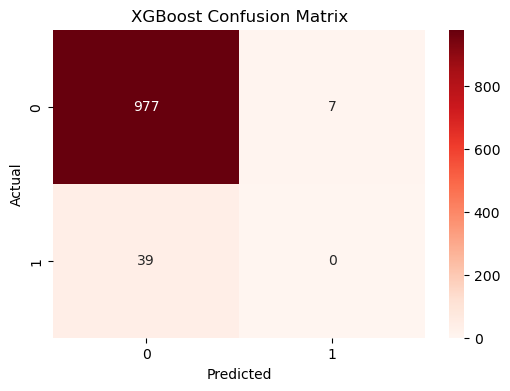

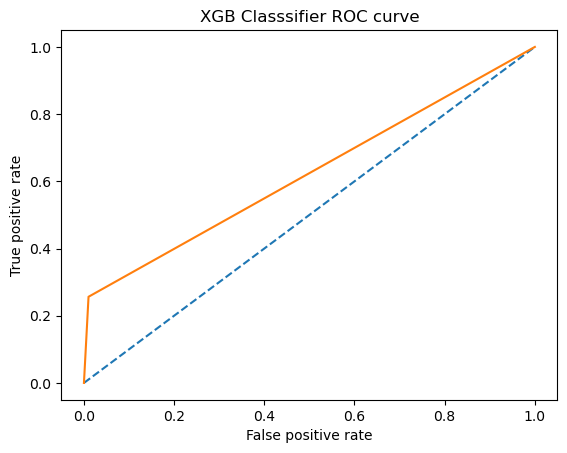

In [71]:
from xgboost import XGBClassifier
from sklearn.metrics import roc_auc_score
from sklearn.metrics import confusion_matrix


model_xgb = XGBClassifier(
    weights = 0.32,
    random_state=42,
    verbosity=0
    )
model_xgb.fit(X_res, y_res)

y_pred_xgb = model_xgb.predict(X_val)
y_prob_xgb = model_xgb.predict_proba(X_val)[:, 1]

print(classification_report(y_val, y_pred_xgb))
print(roc_auc_score(y_val, y_prob_xgb))


plt.figure(figsize=(6, 4))
sns.heatmap(confusion_matrix(y_val, y_pred), annot=True, fmt='d', cmap='Reds')
plt.title('XGBoost Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()


fprXGB, tprXGB, tresholdsXGB = roc_curve(y_val, y_pred_xgb)
plt.plot([0, 1], [0, 1], "--")
plt.plot(fprXGB, tprXGB)
plt.xlabel("False positive rate")
plt.ylabel("True positive rate")
plt.title("XGB Classsifier ROC curve")
plt.show()

In [72]:
y_pred_6 = model_xgb.predict(X_test)
y_prob_6 = model_xgb.predict_proba(X_test)[:,1]
print(classification_report(y_test, y_pred_6))
print(fbeta_score(y_test, y_pred_6, average="macro", beta = 2))
print(round(average_precision_score(y_test, y_prob_6), 3))

              precision    recall  f1-score   support

           0       0.97      0.99      0.98       984
           1       0.59      0.33      0.43        39

    accuracy                           0.97      1023
   macro avg       0.78      0.66      0.70      1023
weighted avg       0.96      0.97      0.96      1023

0.6763051527903267
0.494


In [73]:
from imblearn.pipeline import make_pipeline
from imblearn.combine import SMOTETomek
from sklearn.model_selection import cross_val_score

In [74]:
from sklearn.ensemble import RandomForestClassifier

              precision    recall  f1-score   support

           0       0.97      0.99      0.98       984
           1       0.58      0.18      0.27        39

    accuracy                           0.96      1023
   macro avg       0.78      0.59      0.63      1023
weighted avg       0.95      0.96      0.95      1023

0.9261387325411715


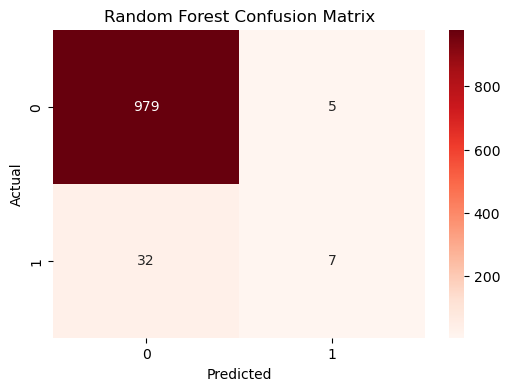

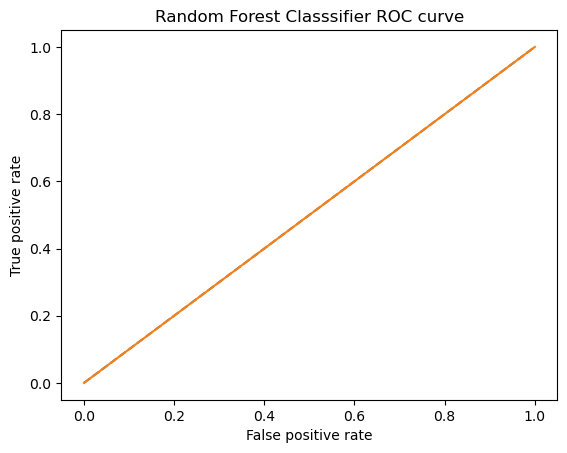

0.13598140211043436


In [75]:
rfc_tl = RandomForestClassifier(random_state=42)
rfc_tl.fit(X_res, y_res)

y_pred_rfc_tl = rfc_tl.predict(X_val)
y_prob_rfc_tl = rfc_tl.predict_proba(X_val)[:, 1]

print(classification_report(y_val, y_pred_rfc_tl))
print(roc_auc_score(y_val, y_prob_rfc_tl))


plt.figure(figsize=(6, 4))
sns.heatmap(confusion_matrix(y_val, y_pred_rfc_tl), annot=True, fmt='d', cmap='Reds')
plt.title('Random Forest Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()


fpr_rfc_tl, tpr_rfc_tl, tresholds_rfc_tl = roc_curve(y_val, y_pred_rfc_tl)
plt.plot([0, 1], [0, 1], "--")
plt.plot(fpr_rfc_tl, fpr_rfc_tl)
plt.xlabel("False positive rate")
plt.ylabel("True positive rate")
plt.title("Random Forest Classsifier ROC curve")
plt.show()

print(average_precision_score(y_val, y_pred_rfc_tl))

In [76]:
y_pred_rcf = rfc_tl.predict(X_test)
y_prob_rcf = rfc_tl.predict_proba(X_test)[:,1]
print(classification_report(y_test, y_pred_rcf))
print(fbeta_score(y_test, y_pred_rcf, average="macro", beta = 2))
print(round(average_precision_score(y_test, y_prob_rcf), 3))

              precision    recall  f1-score   support

           0       0.97      1.00      0.98       984
           1       0.75      0.15      0.26        39

    accuracy                           0.97      1023
   macro avg       0.86      0.58      0.62      1023
weighted avg       0.96      0.97      0.95      1023

0.5873228369730678
0.484


In [77]:
smtl = SMOTETomek(tomek=TomekLinks(sampling_strategy='majority'), random_state=42) 
X_smotek, y_smotek = smtl.fit_resample(X_train, y_train)
total_positive_examples_smotek = y_smotek.value_counts()[1]
total_negative_examples_smotek = y_smotek.value_counts()[0]
esitmate_smotek = total_negative_examples_smotek / total_positive_examples_smotek
print(esitmate_smotek)

0.9933059814294969


/opt/anaconda3/lib/python3.12/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(
/opt/anaconda3/lib/python3.12/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(
/opt/anaconda3/lib/python3.12/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(


              precision    recall  f1-score   support

           0       0.98      0.98      0.98       984
           1       0.53      0.46      0.49        39

    accuracy                           0.96      1023
   macro avg       0.75      0.72      0.74      1023
weighted avg       0.96      0.96      0.96      1023

0.9472847613091515


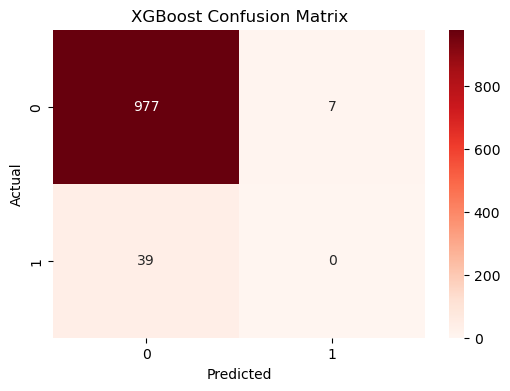

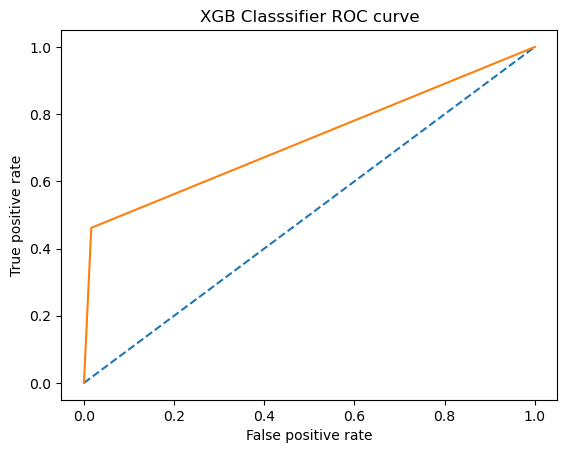

0.4642841225656798


In [78]:
model_xgb_smotek = XGBClassifier(
    random_state=42,
    verbosity=0
    )
model_xgb_smotek.fit(X_smotek, y_smotek)

y_pred_xgb_smotek = model_xgb_smotek.predict(X_val)
y_prob_xgb_smotek = model_xgb_smotek.predict_proba(X_val)[:, 1]

print(classification_report(y_val, y_pred_xgb_smotek))
print(roc_auc_score(y_val, y_prob_xgb_smotek))


plt.figure(figsize=(6, 4))
sns.heatmap(confusion_matrix(y_val, y_pred), annot=True, fmt='d', cmap='Reds')
plt.title('XGBoost Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()


fprXGBS, tprXGBS, tresholdsXGBS = roc_curve(y_val, y_pred_xgb_smotek)
plt.plot([0, 1], [0, 1], "--")
plt.plot(fprXGBS, tprXGBS)
plt.xlabel("False positive rate")
plt.ylabel("True positive rate")
plt.title("XGB Classsifier ROC curve")
plt.show()
print(average_precision_score(y_val, y_prob_xgb_smotek))


In [79]:
y_pred_7 = model_xgb_smotek.predict(X_test)
y_prob_7 = rfc_tl.predict_proba(X_test)[:,1]

print(classification_report(y_test, y_pred_7))
print(fbeta_score(y_test, y_pred_7, average="macro", beta = 2))
print(round(average_precision_score(y_test, y_prob_7), 3))

              precision    recall  f1-score   support

           0       0.98      0.99      0.98       984
           1       0.56      0.38      0.45        39

    accuracy                           0.96      1023
   macro avg       0.77      0.69      0.72      1023
weighted avg       0.96      0.96      0.96      1023

0.6976187627138926
0.484


              precision    recall  f1-score   support

           0       0.98      0.98      0.98       984
           1       0.48      0.56      0.52        39

    accuracy                           0.96      1023
   macro avg       0.73      0.77      0.75      1023
weighted avg       0.96      0.96      0.96      1023

0.9607567229518449


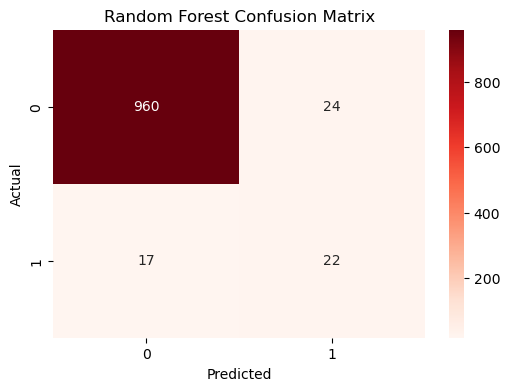

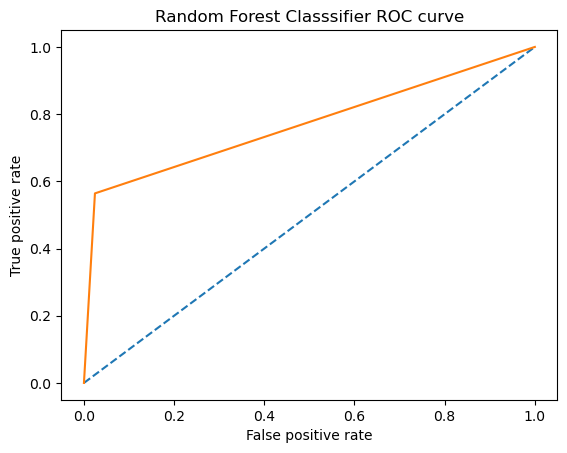

0.45841539719723967


In [80]:
rfc = RandomForestClassifier(random_state=42)
rfc.fit(X_smotek, y_smotek)

y_pred_rfc_smotek = rfc.predict(X_val)
y_prob_rfc_smotek = rfc.predict_proba(X_val)[:, 1]

print(classification_report(y_val, y_pred_rfc_smotek))
print(roc_auc_score(y_val, y_prob_rfc_smotek))


plt.figure(figsize=(6, 4))
sns.heatmap(confusion_matrix(y_val, y_pred_rfc_smotek), annot=True, fmt='d', cmap='Reds')
plt.title('Random Forest Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()


fprXGBS, tprXGBS, tresholdsXGBS = roc_curve(y_val, y_pred_rfc_smotek)
plt.plot([0, 1], [0, 1], "--")
plt.plot(fprXGBS, tprXGBS)
plt.xlabel("False positive rate")
plt.ylabel("True positive rate")
plt.title("Random Forest Classsifier ROC curve")
plt.show()

print(average_precision_score(y_val, y_prob_rfc_smotek))

In [81]:
y_pred_8 = rfc.predict(X_test)
y_prob_8 = rfc.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred_8))
print(fbeta_score(y_test, y_pred_8, average="macro", beta = 2))
print(round(average_precision_score(y_test, y_prob_8), 3))

              precision    recall  f1-score   support

           0       0.98      0.97      0.97       984
           1       0.38      0.44      0.40        39

    accuracy                           0.95      1023
   macro avg       0.68      0.70      0.69      1023
weighted avg       0.95      0.95      0.95      1023

0.6978082724351381
0.364


In [82]:
importances = rfc.feature_importances_
feature_names = df.columns
feature_importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})

# Rank features by importance
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)
print(feature_importance_df)

# Select top N features (example selecting top 10 features)
top_features = feature_importance_df['Feature'][:20].values
X_train_selected = X_smotek[top_features]
X_val_selected = X_val[top_features]

                                  Feature  Importance
7             After-tax net Interest Rate    0.062364
35             Total debt/Total net worth    0.058523
85             Net Income to Total Assets    0.050237
9    Continuous interest rate (after tax)    0.048546
67      Retained Earnings to Total Assets    0.046177
..                                    ...         ...
38   Long-term fund suitability ratio (A)    0.002283
81                          CFO to Assets    0.002262
53        Working Capital to Total Assets    0.002241
84                  Liability-Assets Flag    0.000000
93                        Net Income Flag    0.000000

[95 rows x 2 columns]


In [83]:
print(X_val_selected.columns)
print(X_train_selected.columns)

Index([' After-tax net Interest Rate', ' Total debt/Total net worth',
       ' Net Income to Total Assets', ' Continuous interest rate (after tax)',
       ' Retained Earnings to Total Assets', ' Pre-tax net Interest Rate',
       ' Net Income to Stockholder's Equity', ' Borrowing dependency',
       ' Total income/Total expense',
       ' Persistent EPS in the Last Four Seasons',
       ' Net profit before tax/Paid-in capital',
       ' ROA(A) before interest and % after tax',
       ' Per Share Net profit before tax (Yuan ¥)', ' Liability to Equity',
       ' Debt ratio %', ' Net worth/Assets',
       ' Non-industry income and expenditure/revenue',
       ' Current Liabilities/Equity',
       ' ROA(B) before interest and depreciation after tax',
       ' Net Value Growth Rate'],
      dtype='object')
Index([' After-tax net Interest Rate', ' Total debt/Total net worth',
       ' Net Income to Total Assets', ' Continuous interest rate (after tax)',
       ' Retained Earnings to Total A

              precision    recall  f1-score   support

           0       0.99      0.94      0.97       984
           1       0.33      0.72      0.46        39

    accuracy                           0.93      1023
   macro avg       0.66      0.83      0.71      1023
weighted avg       0.96      0.93      0.95      1023

0.949747237856994


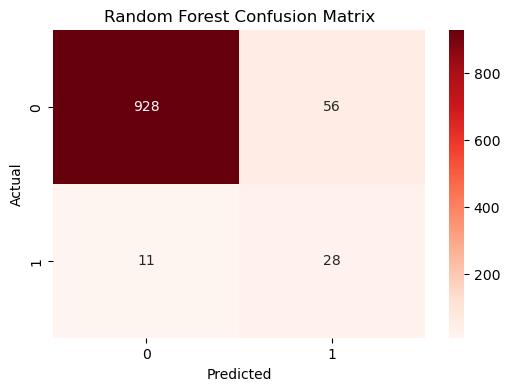

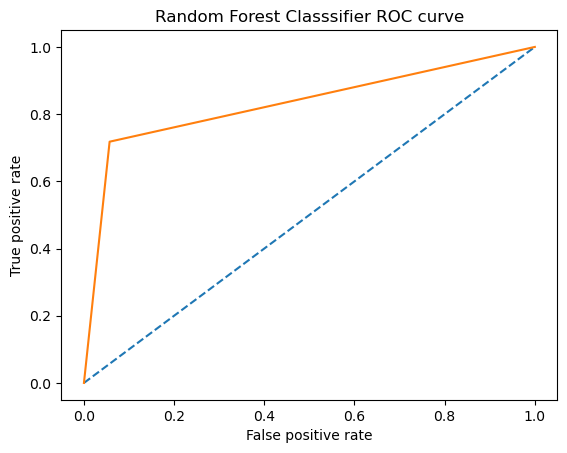

0.42881989006711424


In [84]:
rfc_sel = RandomForestClassifier(random_state=42)
rfc_sel.fit(X_train_selected, y_smotek)

y_pred_rfc_smotek_sel = rfc_sel.predict(X_val_selected)
y_prob_rfc_smotek_sel = rfc_sel.predict_proba(X_val_selected)[:, 1]

print(classification_report(y_val, y_pred_rfc_smotek_sel))
print(roc_auc_score(y_val, y_prob_rfc_smotek_sel))


plt.figure(figsize=(6, 4))
sns.heatmap(confusion_matrix(y_val, y_pred_rfc_smotek_sel), annot=True, fmt='d', cmap='Reds')
plt.title('Random Forest Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()


fpr_rfc_sel, tpr_rfc_sel, tresholds_rfc_sel = roc_curve(y_val, y_pred_rfc_smotek_sel)
plt.plot([0, 1], [0, 1], "--")
plt.plot(fpr_rfc_sel, tpr_rfc_sel)
plt.xlabel("False positive rate")
plt.ylabel("True positive rate")
plt.title("Random Forest Classsifier ROC curve")
plt.show()

print(average_precision_score(y_val, y_prob_rfc_smotek_sel))

In [85]:
y_pred_9 = rfc_sel.predict(X_test[top_features])
y_prob_9 = rfc_sel.predict_proba(X_test[top_features])[:, 1]

print(classification_report(y_test, y_pred_9))
print(fbeta_score(y_test, y_pred_9, average="macro", beta = 2))
print(round(average_precision_score(y_test, y_pred_9), 3))

              precision    recall  f1-score   support

           0       0.99      0.95      0.96       984
           1       0.32      0.64      0.42        39

    accuracy                           0.93      1023
   macro avg       0.65      0.79      0.69      1023
weighted avg       0.96      0.93      0.94      1023

0.7423918730380188
0.217


# Models performance on test set

              precision    recall  f1-score   support

           0       0.98      0.99      0.98       984
           1       0.56      0.38      0.45        39

    accuracy                           0.96      1023
   macro avg       0.77      0.69      0.72      1023
weighted avg       0.96      0.96      0.96      1023

0.9427246195538879


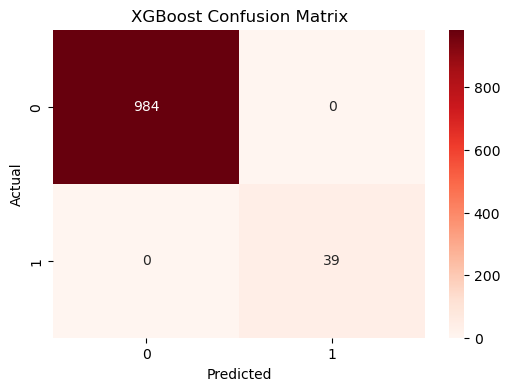

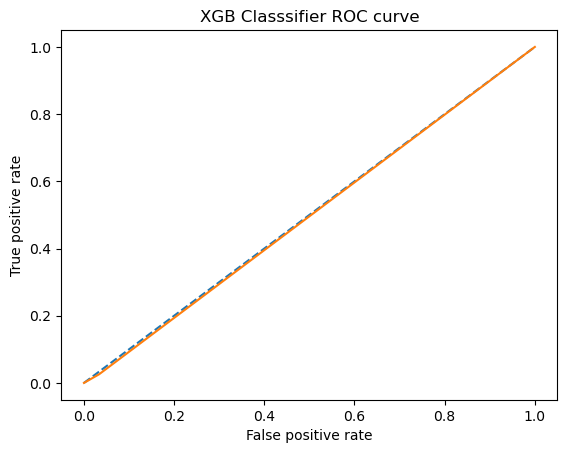

0.5212988960351564


In [86]:
y_pred_xgb_smotek_test = model_xgb_smotek.predict(X_test)
y_prob_xgb_smotek_test = model_xgb_smotek.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred_xgb_smotek_test))
print(roc_auc_score(y_test, y_prob_xgb_smotek_test))


plt.figure(figsize=(6, 4))
sns.heatmap(confusion_matrix(y_test, y_test), annot=True, fmt='d', cmap='Reds')
plt.title('XGBoost Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()


fprXGBS, tprXGBS, tresholdsXGBS = roc_curve(y_test, y_pred_xgb_smotek)
plt.plot([0, 1], [0, 1], "--")
plt.plot(fprXGBS, tprXGBS)
plt.xlabel("False positive rate")
plt.ylabel("True positive rate")
plt.title("XGB Classsifier ROC curve")
plt.show()
print(average_precision_score(y_test, y_prob_xgb_smotek_test))